In [1]:
#pip install ordered-set

In [2]:
#pip install dill==0.3.5

In [1]:
# LATEST UPDATE OF THE STATE OF THINGS

# IMPORTANT: NNholo is NOT the original code, it's an old version of the new architecture (NEED TO FIX THIS)

# I have here NNholo (original code) and NNholo new_arch (a copy with the new architecture). Plan is to:

# 1. Compare running times of old vs new arch
# 2. Add new equations derived from Pedro's notebook (NEC and from compressed Bianchi identities) to the new_arch code. Try to do runs to compare them with normal ones.

# 3. On the other window, continue working on the attention layer.

# 4. Pedro managed to get profiles of the naked singularity potentials (NS). Check that out to understand (Javi's paper). Can we implement these potentials?  

In [2]:
import os
import json
os.environ["DEV"] = "1"
os.environ["NEURODIFF_API_URL"] = "http://dev.neurodiff.io"
os.environ["NEURODIFF_API_KEY"] = 'tNaaIvvvdg72-c8VcTZRgpALsl0ns77ljEvxul6tG0E'

import warnings
warnings.filterwarnings("ignore")
import dill
dill.__version__

import numpy
from NNholo_new_arch import *
from tqdm.auto import tqdm
import shutil

## Create directory for results

In [3]:
# Directory 
directory = "test_SofTphiM5_0"
# Parent Directory path 
parent_dir = "../Results/example/Architecture test/Energy conditions/New arch"
# Path 
path_results = os.path.join(parent_dir, directory) 

In [4]:
if os.path.exists(path_results):
    shutil.rmtree(path_results)
os.mkdir(path_results) 
print("Directory '% s' created" % directory) 

Directory 'test_SofTphiM5_0' created


## Generate model

In [5]:
c = NNholo(data_path = "../Data/SofT/SofTphiM5_0.txt", \
           saving_path = path_results,sampling_method='chebyshev2', init_pt_curve = 55, delta = 0.0, curriculum = 1.0)



File is .txt
MeshGenerator(size=None)

Test outputs:
net_a output shape: torch.Size([10, 4])
net_b output shape: torch.Size([10, 2])


In [6]:
import time
from datetime import datetime

def train_and_time(nn_holo_instance, epochs, callbacks, desc="Training"):
    """
    Train a model and measure execution time
    
    Args:
        nn_holo_instance: NNholo instance
        epochs: Number of epochs to train
        callbacks: List of callbacks for training
        desc: Description for the progress bar
        
    Returns:
        dict with timing results and training metrics
    """
    start_time = time.time()
    
    # Train the model
    nn_holo_instance.solver.fit(
        max_epochs=epochs,
        callbacks=callbacks,
        tqdm_file=tqdm(total=epochs, dynamic_ncols=True, 
                      desc=desc, unit='iteration', colour='#0afa9e')
    )
    
    end_time = time.time()
    
    # Calculate timing metrics
    total_seconds = end_time - start_time
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    results = {
        'total_seconds': total_seconds,
        'formatted_time': f"{int(hours)}h {int(minutes)}m {seconds:.2f}s",
        'epochs': epochs,
        'seconds_per_epoch': total_seconds / epochs,
        'final_loss': nn_holo_instance.solver.metrics_history['train_loss'][-1]
    }
    
    with open('training_results.json', 'w') as f:
       json.dump(results, f, indent=4)
    
    return results

In [7]:
# def check_generator_outputs(model):
#     """
#     Debug function to check generator outputs
#     """
#     print("\nChecking train generator:")
#     train_outputs = model.train_generator.get_examples()
#     for i, out in enumerate(train_outputs):
#         print(f"Output {i} shape:", out.shape)
    
#     print("\nChecking valid generator:")
#     valid_outputs = model.valid_generator.get_examples()
#     for i, out in enumerate(valid_outputs):
#         print(f"Output {i} shape:", out.shape)

# # Use it after model initialization
# check_generator_outputs(c)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


S_min:  tensor(0.)
Length of input s(T) curve:  torch.Size([61])


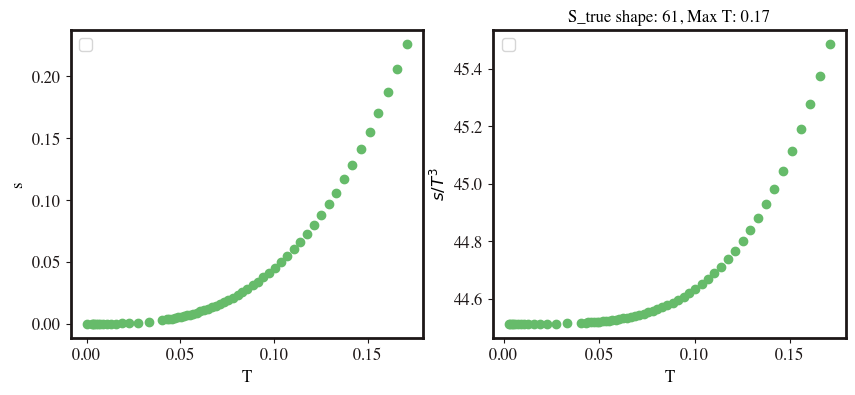

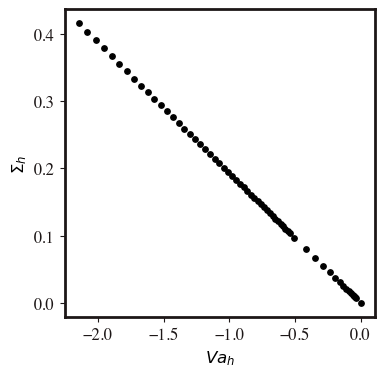

In [8]:
c.sofT_curve()

In [9]:
store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(c.adam, step_size=5000, gamma=0.985)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()

In [10]:
# RUN CELL BELOW FOR TIME TRACKING!

In [12]:
# Time the training
results = train_and_time(c, epochs=1000, callbacks=[potential_cb, scheduler_cb])

print(f"Training took {results['formatted_time']}")
print(f"Seconds per epoch: {results['seconds_per_epoch']:.3f}")

Training:   0%|          | 0/1000 [00:00<?, ?iteration/s]

Training took 0h 0m 31.15s
Seconds per epoch: 0.031


In [54]:
residuals = c.get_residuals(display = True)
print(residuals)

Mean of residuals : 0.020490068.
[[[ 3.15490862e-01  3.09042549e-01  3.02026451e-01 ...  1.80536391e-02
    1.86485831e-02  2.17693927e-02]
  [ 3.58478865e-01  3.51726600e-01  3.44398790e-01 ...  4.87508071e-02
    4.92432784e-02  5.18564890e-02]
  [ 4.02486003e-01  3.95562627e-01  3.88053459e-01 ...  7.53858794e-02
    7.57152403e-02  7.75346739e-02]
  ...
  [ 3.43614342e-01  3.40561904e-01  3.37004757e-01 ... -1.52252238e-01
   -1.54074073e-01 -1.62454217e-01]
  [ 2.89171789e-01  2.86172722e-01  2.82685041e-01 ... -2.02932580e-01
   -2.04717285e-01 -2.12913391e-01]
  [ 2.35469782e-01  2.32461844e-01  2.28975743e-01 ... -2.50762194e-01
   -2.52471148e-01 -2.60301389e-01]]

 [[ 1.28998115e-01  1.43228899e-01  1.54724096e-01 ... -3.74916328e-01
   -3.76967843e-01 -3.86219421e-01]
  [-1.46571559e-02  5.21408593e-03  2.24272841e-02 ... -2.52168761e-01
   -2.53261152e-01 -2.57964881e-01]
  [-1.21053742e-01 -9.65112780e-02 -7.45816841e-02 ... -1.47725548e-01
   -1.48054476e-01 -1.49135948e-

In [53]:
residuals.shape

(7, 16, 61)

In [57]:
976/16

61.0

In [48]:
batch = [v.reshape(-1, 1) for v in c.valid_generator.get_examples()]
print(batch)
len(batch[0])

[tensor([[0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [0.0000],
        [

976

In [50]:
functions = [c.solver.compute_func_val(a, b, *batch) for a, b in zip(c.solver.nets, c.solver.conditions)]
functions[0].shape

torch.Size([976, 1])

In [8]:
#c.update_optimizer(lr = 5e-5)

In [8]:
epochs = 1000000
c.solver.fit(max_epochs=epochs, 
             callbacks=[potential_cb, scheduler_cb], 
             tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))



Epochs:   0%|          | 0/1000000 [00:00<?, ?iteration/s]

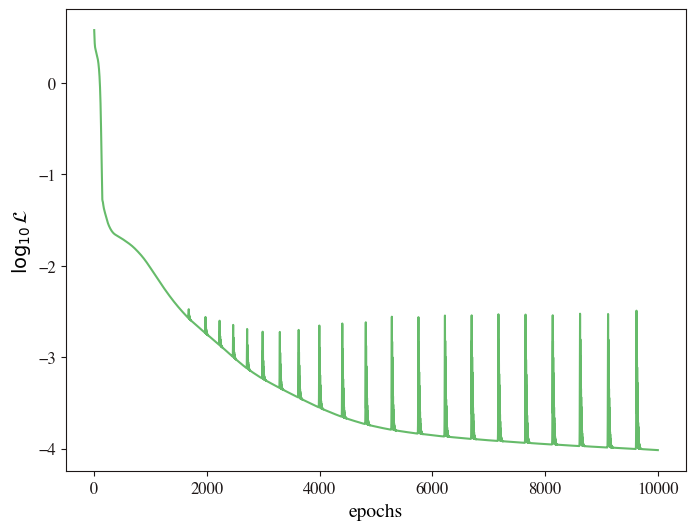

Min loss:  9.611255757213047e-05
max phi_h=  1.0252765772330528


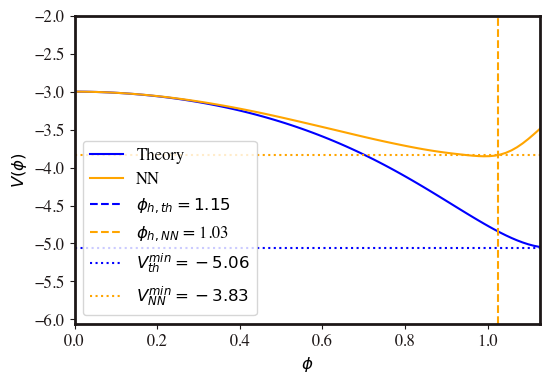

In [27]:
c.plot_loss()
c.plot_potential(phim = 5.0)
#c.plot_colored_sofT(phiM_chosen=2.0)

max phi_h=  1.0252765772330528


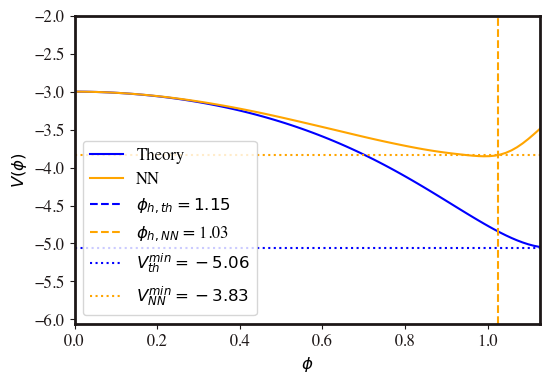

In [28]:
c.plot_potential(phim = 5) #your value of phi_M associated with intup s(T) curve

In [29]:
c.update_optimizer() #If empty gives current state of optimizer

Actual learning rate:  0.000970225


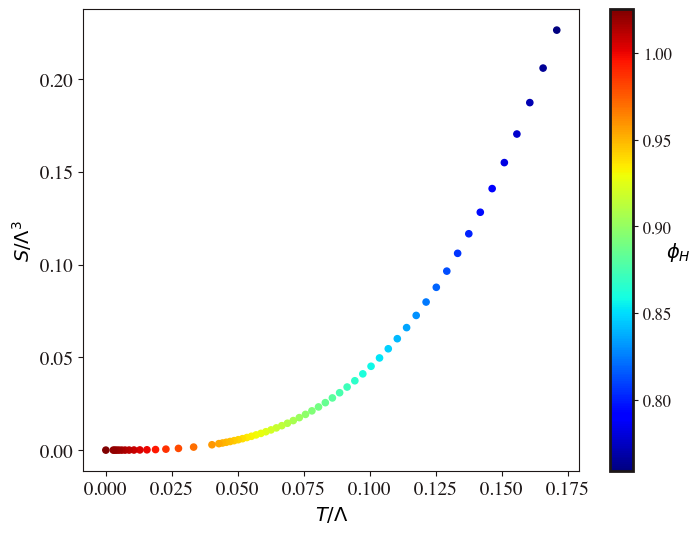

In [30]:
c.plot_colored_sofT(phiM_chosen = 0.58, colormap = 'jet', fontsize = 14, n_fontsize = 14, \
                          dot_size=20, thick=0.8, figsize = (8,6))

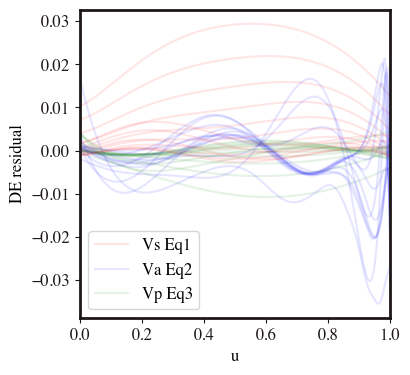

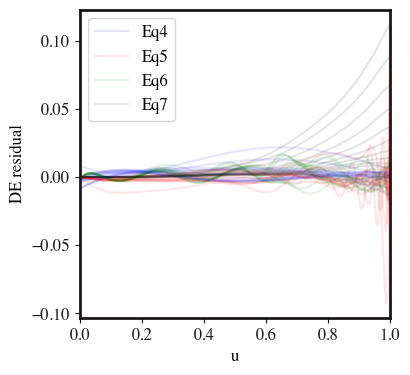

In [31]:
c.plot_residuals_in_u(max_bound = False, print_overbound = False, save_plot=False)


Point 1 ; phi_h_yago = 0.600000


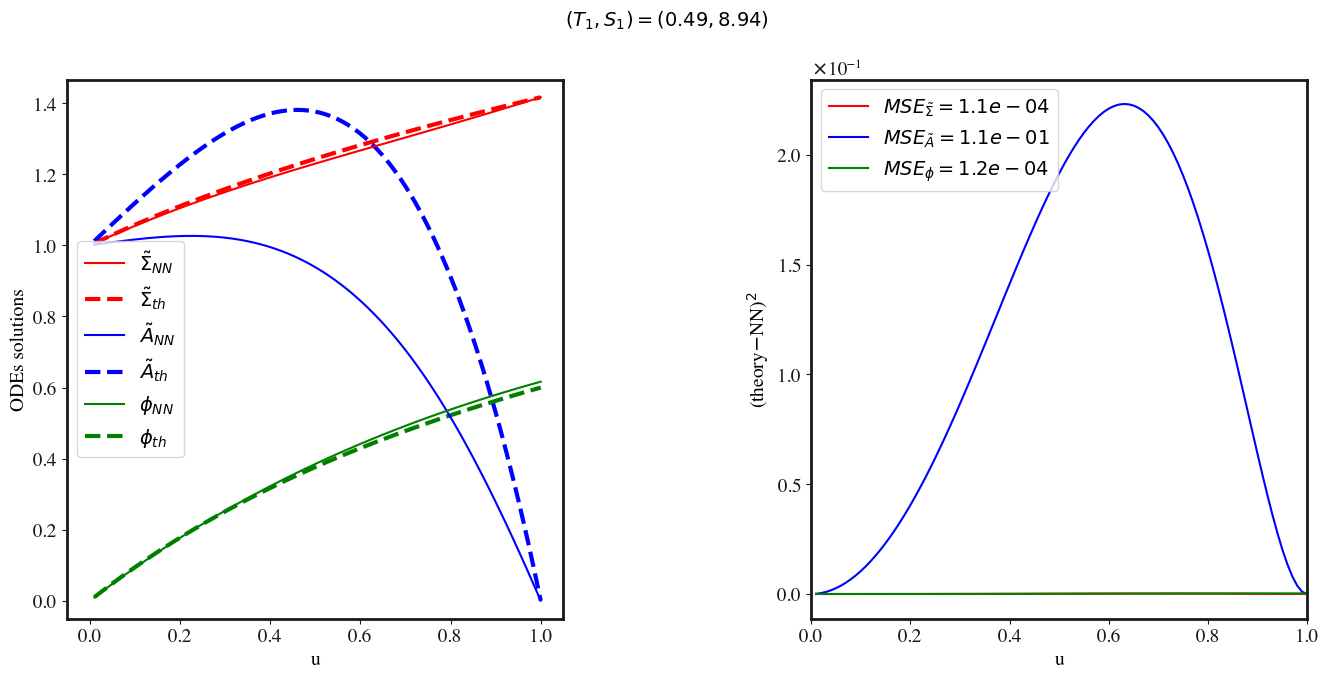

Point 2 ; phi_h_yago = 1.411452


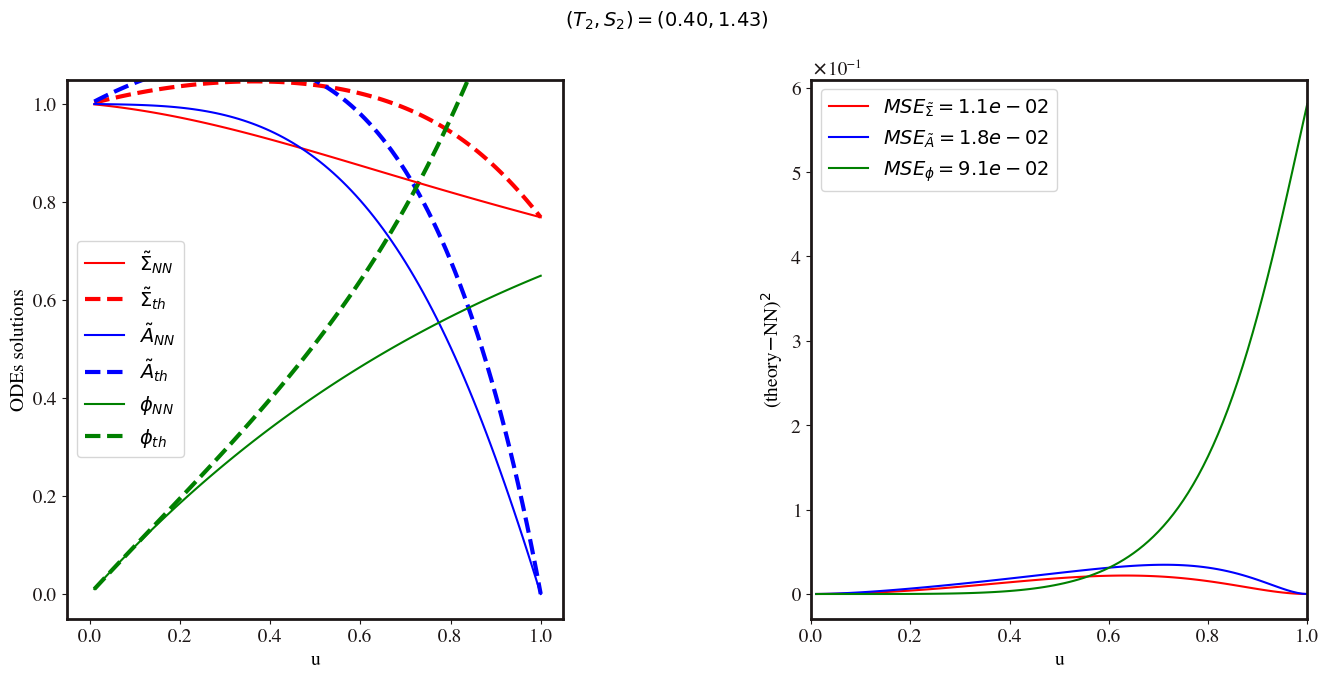

Point 3 ; phi_h_yago = 1.528000


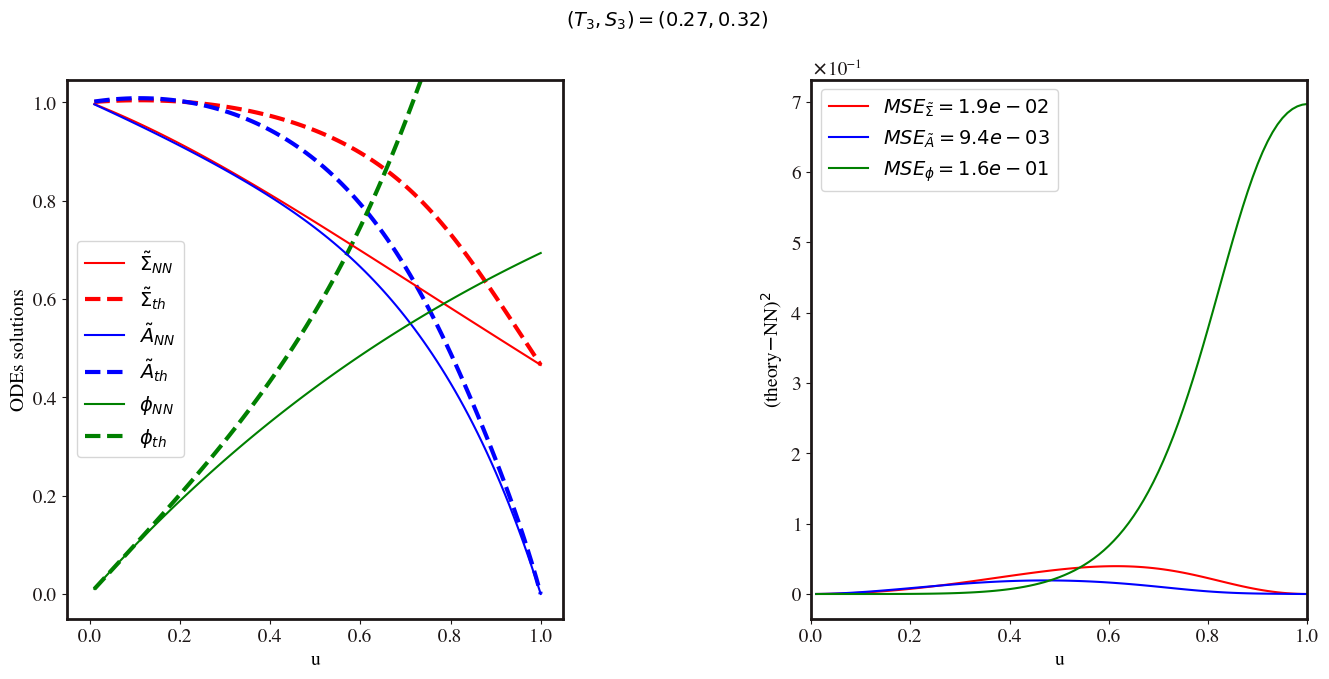

In [32]:
c.compare_to_yago(fontsize = 14, legend_fontsize=14, n_fontsize=14, \
                wspace=0.5, yago_linewidth = 3, yago_style = '--')


### Save the trained model:

In [33]:
c.save_results(f'{path_results}/trained_NN')